# Codeboosters Tech Phase 1 Capstone Project
## Data Engineering



In this step, a Pass-Fail student dataset in CSV format is selected from Kaggle for performing data engineering, analytics, visualization, and machine learning tasks.

In [1]:
import pandas as pd

***Importing Libraries***

In [5]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import os
print('successfully imported')

successfully imported


***Load CSV Dataset***



In this step, the CSV dataset is loaded into a Pandas DataFrame to analyze the dataset structure, columns, data types, missing values, and duplicate records

In [6]:
df = pd.read_csv("Pass-Fail Data.csv")

In [7]:
df.head()

,student_id,attendance_pct,homework_pct,midterm_score,study_hours_per_week,pass
0,1,95,92,88,12,1
1,2,88,85,79,10,1
2,3,60,55,58,4,0
3,4,72,70,65,6,1
4,5,40,45,50,3,0



In this step, the overall structure of the dataset including shape, column names, data types, missing values, and duplicate records is analyzed for better understanding of the data.

In [8]:
print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Records:")
print(df.duplicated().sum())

Dataset Shape: (100, 6)

Columns:
Index(['student_id', 'attendance_pct', 'homework_pct', 'midterm_score',
       'study_hours_per_week', 'pass'],
      dtype='object')

Data Types:
student_id              int64
attendance_pct          int64
homework_pct            int64
midterm_score           int64
study_hours_per_week    int64
pass                    int64
dtype: object

Missing Values:
student_id              0
attendance_pct          0
homework_pct            0
midterm_score           0
study_hours_per_week    0
pass                    0
dtype: int64

Duplicate Records:
0


***Data*** **Cleaning**

In [9]:
df_clean = df.copy()

In [10]:
df_clean = df_clean.drop_duplicates()

In [11]:
for col in df_clean.columns:

    if df_clean[col].dtype == 'object':

        df_clean[col] = df_clean[col].fillna(
            df_clean[col].mode()[0]
        )

    else:

        df_clean[col] = df_clean[col].fillna(
            df_clean[col].median()
        )

In [12]:
df_clean.columns = df_clean.columns.str.lower().str.replace(" ","_")

In [13]:
print(df_clean.isnull().sum())
print("Duplicates:", df_clean.duplicated().sum())

student_id              0
attendance_pct          0
homework_pct            0
midterm_score           0
study_hours_per_week    0
pass                    0
dtype: int64
Duplicates: 0


***Save Cleaned Dataset***

In [14]:
df_clean.to_csv(
    "cleaned_pass_fail_dataset.csv",
    index=False
)

print("Cleaned dataset saved")

Cleaned dataset saved


***SQLite Database Integration***

In [16]:
conn = sqlite3.connect(
    "pass_fail_database.db"
)

In [17]:
df_clean.to_sql(
    "student_data",
    conn,
    if_exists="replace",
    index=False
)

print("Data inserted successfully")

Data inserted successfully


In [18]:
query = "SELECT * FROM student_data LIMIT 5"

pd.read_sql(query, conn)

,student_id,attendance_pct,homework_pct,midterm_score,study_hours_per_week,pass
0,1,95,92,88,12,1
1,2,88,85,79,10,1
2,3,60,55,58,4,0
3,4,72,70,65,6,1
4,5,40,45,50,3,0


In [19]:
query = "SELECT * FROM student_data LIMIT 5"

pd.read_sql(query, conn)

,student_id,attendance_pct,homework_pct,midterm_score,study_hours_per_week,pass
0,1,95,92,88,12,1
1,2,88,85,79,10,1
2,3,60,55,58,4,0
3,4,72,70,65,6,1
4,5,40,45,50,3,0


In [21]:
print(df_clean.columns)

Index(['student_id', 'attendance_pct', 'homework_pct', 'midterm_score',
       'study_hours_per_week', 'pass'],
      dtype='object')


***SQL Queries***

***Filtering***

In [22]:
query1 = """
SELECT *
FROM student_data
WHERE attendance_pct > 80
"""

pd.read_sql(query1, conn)

,student_id,attendance_pct,homework_pct,midterm_score,study_hours_per_week,pass
0,1,95,92,88,12,1
1,2,88,85,79,10,1
2,6,85,90,91,14,1
3,9,90,88,84,11,1
4,12,82,78,76,9,1
5,15,92,95,93,15,1
6,19,88,90,86,12,1
7,22,83,80,78,9,1
8,25,90,88,85,11,1
9,28,86,84,80,10,1


***Sorting Query***

In [23]:
query2 = """
SELECT *
FROM student_data
ORDER BY midterm_score DESC
"""

pd.read_sql(query2, conn)

,student_id,attendance_pct,homework_pct,midterm_score,study_hours_per_week,pass
0,75,94,96,97,15,1
1,45,93,94,95,15,1
2,96,89,92,94,14,1
3,15,92,95,93,15,1
4,66,88,91,93,14,1
...,...,...,...,...,...,...
95,53,36,41,47,2,0
96,83,38,42,46,2,0
97,41,33,38,45,2,0
98,71,34,39,44,2,0


***Aggregation Query***

In [24]:
query3 = """
SELECT AVG(study_hours_per_week) AS avg_study_hours
FROM student_data
"""

pd.read_sql(query3, conn)

,avg_study_hours
0,7.28


***Group By Query***

In [25]:
query4 = """
SELECT pass, COUNT(*) AS total_students
FROM student_data
GROUP BY pass
"""

pd.read_sql(query4, conn)

,pass,total_students
0,0,40
1,1,60


***Conditional Query***

In [26]:
query5 = """
SELECT *,

CASE
    WHEN midterm_score >= 75 THEN 'Excellent'
    WHEN midterm_score >= 50 THEN 'Average'
    ELSE 'Poor'
END AS performance

FROM student_data
"""

pd.read_sql(query5, conn)

,student_id,attendance_pct,homework_pct,midterm_score,study_hours_per_week,pass,performance
0,1,95,92,88,12,1,Excellent
1,2,88,85,79,10,1,Excellent
2,3,60,55,58,4,0,Average
3,4,72,70,65,6,1,Average
4,5,40,45,50,3,0,Average
...,...,...,...,...,...,...,...
95,96,89,92,94,14,1,Excellent
96,97,79,77,75,8,1,Excellent
97,98,55,56,58,5,0,Average
98,99,91,90,88,12,1,Excellent


***SQL-Based Data Transformation***

In [27]:
query_transform = """

SELECT *,

CASE
    WHEN attendance_pct >= 75 THEN 'Good Attendance'
    ELSE 'Low Attendance'
END AS attendance_status,

CASE
    WHEN study_hours_per_week >= 15 THEN 'High Study'
    ELSE 'Low Study'
END AS study_category

FROM student_data

"""

df_transformed = pd.read_sql(query_transform, conn)

df_transformed.head()

,student_id,attendance_pct,homework_pct,midterm_score,study_hours_per_week,pass,attendance_status,study_category
0,1,95,92,88,12,1,Good Attendance,Low Study
1,2,88,85,79,10,1,Good Attendance,Low Study
2,3,60,55,58,4,0,Low Attendance,Low Study
3,4,72,70,65,6,1,Low Attendance,Low Study
4,5,40,45,50,3,0,Low Attendance,Low Study


In [28]:
df_transformed.to_csv(
    "transformed_student_dataset.csv",
    index=False
)

print("Transformed dataset exported")

Transformed dataset exported


***ETL Pipeline***

In [30]:
def extract(file):
    return pd.read_csv(file)


def transform(data):

    data = data.drop_duplicates()

    for col in data.columns:

        if data[col].dtype == 'object':
            data[col] = data[col].fillna(data[col].mode()[0])

        else:
            data[col] = data[col].fillna(data[col].median())

    return data


def load(data, output):

    data.to_csv(output, index=False)

    print("ETL Pipeline Completed")


raw_data = extract("Pass-Fail Data.csv")

processed_data = transform(raw_data)

load(processed_data, "etl_output.csv")

ETL Pipeline Completed


***PySpark compeltion***

In [31]:
!pip install pyspark

***Create Spark Session***

In [32]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F

spark = SparkSession.builder \
    .appName("Codeboosters_Phase1_Capstone") \
    .getOrCreate()

print("Spark session created successfully")

Spark session created successfully


***Bronze Layer***

In [33]:
bronze_df = spark.read.csv(
    "Pass-Fail Data.csv",
    header=True,
    inferSchema=True
)

bronze_df.show(5)

bronze_df.write.mode("overwrite").parquet("bronze_layer.parquet")

print("Bronze layer saved successfully")

+----------+--------------+------------+-------------+--------------------+----+
|student_id|attendance_pct|homework_pct|midterm_score|study_hours_per_week|pass|
+----------+--------------+------------+-------------+--------------------+----+
|         1|            95|          92|           88|                  12|   1|
|         2|            88|          85|           79|                  10|   1|
|         3|            60|          55|           58|                   4|   0|
|         4|            72|          70|           65|                   6|   1|
|         5|            40|          45|           50|                   3|   0|
+----------+--------------+------------+-------------+--------------------+----+
only showing top 5 rows
Bronze layer saved successfully


***Silver Layer***

In [34]:
silver_df = bronze_df.dropDuplicates().dropna()

silver_df.write.mode("overwrite").parquet("silver_layer.parquet")

print("Silver layer saved successfully")

Silver layer saved successfully


***Gold Layer***
***The Gold Layer contains business-ready aggregated insights such as average attendance, average homework percentage, and average study hours grouped by pass status.***

In [35]:
gold_df = silver_df.groupBy("pass").agg(
    F.count("*").alias("total_students"),
    F.avg("attendance_pct").alias("avg_attendance"),
    F.avg("homework_pct").alias("avg_homework"),
    F.avg("midterm_score").alias("avg_midterm_score"),
    F.avg("study_hours_per_week").alias("avg_study_hours")
)

gold_df.show()

gold_df.write.mode("overwrite").parquet("gold_layer.parquet")

print("Gold layer saved successfully")

+----+--------------+--------------+------------+-----------------+-----------------+
|pass|total_students|avg_attendance|avg_homework|avg_midterm_score|  avg_study_hours|
+----+--------------+--------------+------------+-----------------+-----------------+
|   1|            60|         82.05|       81.05|78.81666666666666|9.666666666666666|
|   0|            40|        50.725|        51.0|           53.725|              3.7|
+----+--------------+--------------+------------+-----------------+-----------------+

Gold layer saved successfully


***CSV vs Parquet Comparison***

In [36]:
import os
import time

start = time.time()
csv_df = pd.read_csv("etl_output.csv")
csv_read_time = time.time() - start

start = time.time()
parquet_df = spark.read.parquet("silver_layer.parquet")
parquet_read_time = time.time() - start

csv_size = os.path.getsize("etl_output.csv") / 1024

parquet_size = sum(
    os.path.getsize("silver_layer.parquet/" + file)
    for file in os.listdir("silver_layer.parquet")
    if file.endswith(".parquet")
) / 1024

comparison_df = pd.DataFrame({
    "Format": ["CSV", "Parquet"],
    "File Size KB": [csv_size, parquet_size],
    "Read Time Seconds": [csv_read_time, parquet_read_time],
    "Storage Efficiency": ["Less Efficient", "More Efficient"],
    "Advantages": [
        "Simple, readable, easy to open",
        "Compressed, faster for big data, supports schema"
    ],
    "Limitations": [
        "Large size, slower for big data",
        "Not directly readable like CSV"
    ]
})

comparison_df

,Format,File Size KB,Read Time Seconds,Storage Efficiency,Advantages,Limitations
0,CSV,1.661133,0.008142,Less Efficient,"Simple, readable, easy to open","Large size, slower for big data"
1,Parquet,3.418945,0.257641,More Efficient,"Compressed, faster for big data, supports schema",Not directly readable like CSV


***Parquet to Pandas Conversion***

In [37]:
spark_parquet_df = spark.read.parquet("silver_layer.parquet")

pandas_from_parquet = spark_parquet_df.toPandas()

print("Parquet converted back to Pandas successfully")

pandas_from_parquet.head()

Parquet converted back to Pandas successfully


,student_id,attendance_pct,homework_pct,midterm_score,study_hours_per_week,pass
0,93,60,58,56,4,0
1,82,85,82,80,9,1
2,44,51,49,53,4,0
3,62,86,84,82,10,1
4,16,65,60,59,5,0


***Visualizations***

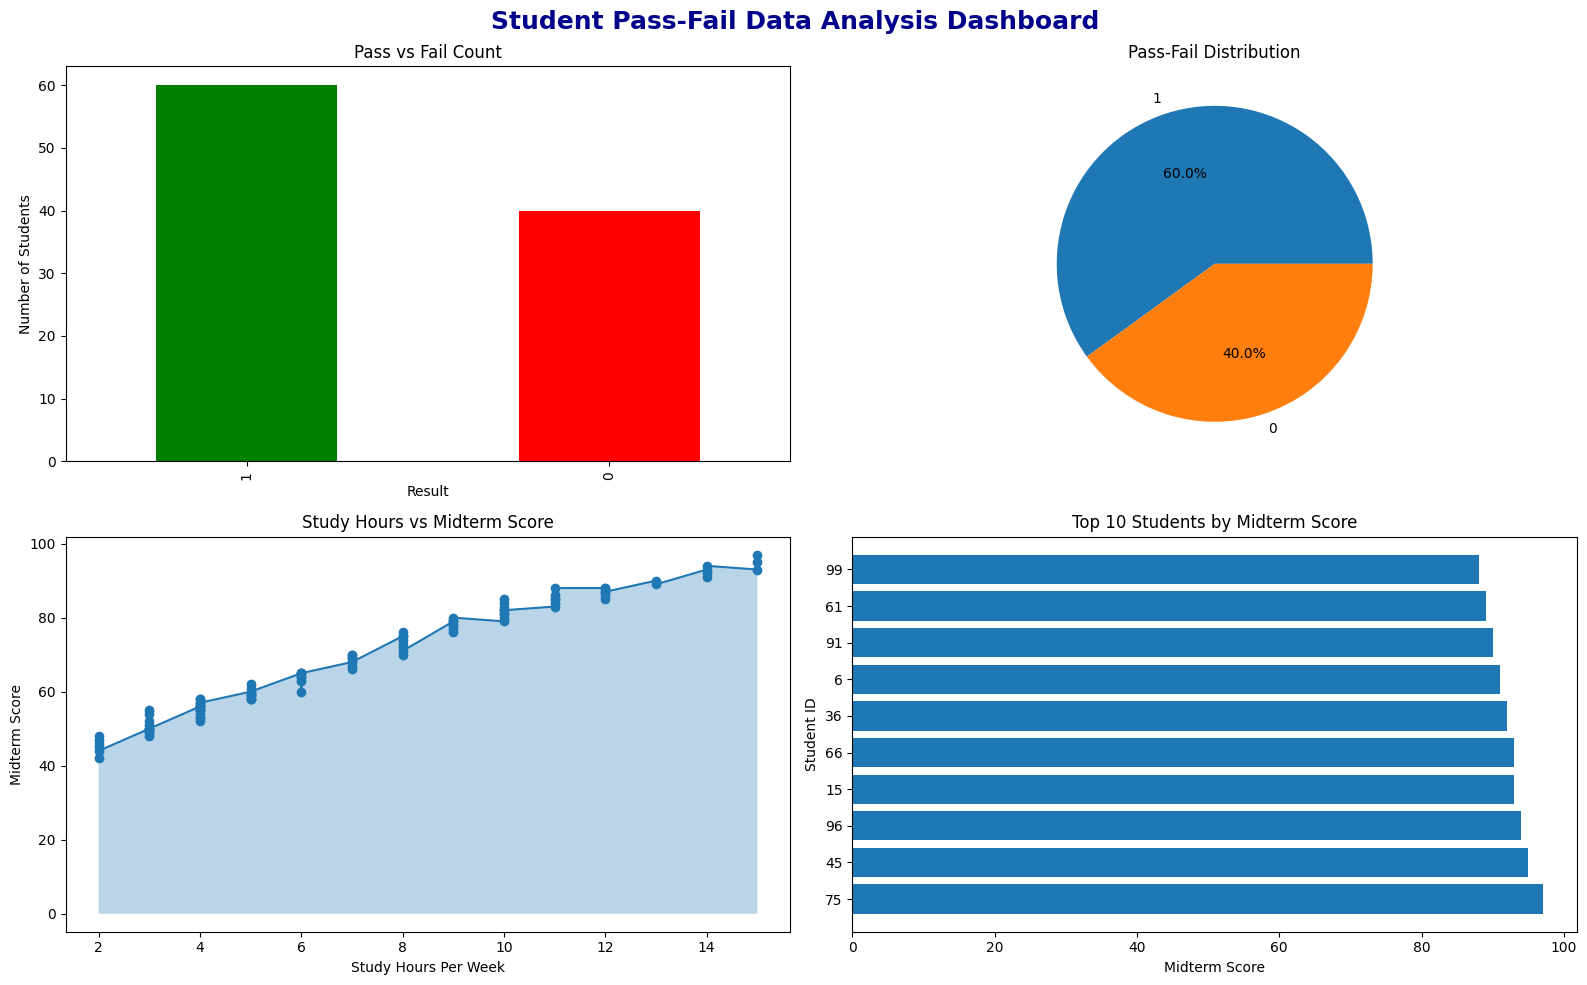

In [39]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

fig.suptitle(
    'Student Pass-Fail Data Analysis Dashboard',
    fontsize=18,
    fontweight='bold',
    color='darkblue'
)
ax1 = axes[0,0]

df_clean['pass'].value_counts().plot(
    kind='bar',
    ax=ax1,
    color=['green', 'red']
)

ax1.set_title('Pass vs Fail Count')
ax1.set_xlabel('Result')
ax1.set_ylabel('Number of Students')
ax2 = axes[0,1]

df_clean['pass'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    ax=ax2
)

ax2.set_title('Pass-Fail Distribution')
ax2.set_ylabel('')
ax3 = axes[1,0]

sorted_df = df_clean.sort_values('study_hours_per_week')

ax3.plot(
    sorted_df['study_hours_per_week'],
    sorted_df['midterm_score'],
    marker='o'
)

ax3.fill_between(
    sorted_df['study_hours_per_week'],
    sorted_df['midterm_score'],
    alpha=0.3
)

ax3.set_title('Study Hours vs Midterm Score')
ax3.set_xlabel('Study Hours Per Week')
ax3.set_ylabel('Midterm Score')

ax4 = axes[1,1]

top_students = df_clean.sort_values(
    'midterm_score',
    ascending=False
).head(10)

ax4.barh(
    top_students['student_id'].astype(str),
    top_students['midterm_score']
)

ax4.set_title('Top 10 Students by Midterm Score')
ax4.set_xlabel('Midterm Score')
ax4.set_ylabel('Student ID')

plt.tight_layout()

plt.show()

Observation:
Most students belong to the Pass category and higher study hours generally lead to higher midterm scores.

***Machine Learning Model***

In [38]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder

ml_df = pd.read_csv("etl_output.csv")

le = LabelEncoder()
ml_df['pass_encoded'] = le.fit_transform(ml_df['pass'])

X = ml_df.drop(['student_id', 'pass', 'pass_encoded'], axis=1)
y = ml_df['pass_encoded']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       1.00      1.00      1.00        12

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20





This project successfully implemented the complete Data Engineering lifecycle including:

- Data ingestion using Pandas
- Data cleaning and preprocessing
- SQLite database integration
- SQL analysis and transformation
- ETL pipeline implementation
- PySpark Medallion Architecture
- CSV vs Parquet comparison
- Data visualization dashboard
- Machine Learning model training and evaluation

The project demonstrates end-to-end data engineering and analytics workflow using Python, SQL, Pandas, PySpark, and Machine Learning.

In [40]:
import shutil

shutil.make_archive(
    'bronze_layer',
    'zip',
    'bronze_layer.parquet'
)

shutil.make_archive(
    'silver_layer',
    'zip',
    'silver_layer.parquet'
)

shutil.make_archive(
    'gold_layer',
    'zip',
    'gold_layer.parquet'
)

print("All parquet folders converted to ZIP successfully")

All parquet folders converted to ZIP successfully
